# **Future Of Deep Learning**

**Laboratorium:** Sieć Feed-Forward w PyTorch

**Zadanie**: Zbuduj klasyfikator chorób serca z użyciem zbioru Heart Disease Dataset

**Dane:** Zbiór heart.csv to klasyczny zestaw danych medycznych używany do predykcji chorób serca. Zawiera informacje o pacjentach (ciągłe i kategoryczne), takie jak wiek, płeć, ciśnienie krwi, poziom cholesterolu czy wyniki badań EKG, a zmienną docelową jest etykieta wskazująca, czy pacjent ma chorobę serca (1) czy nie (0).

**Źródło:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Analiza danych i przygotowanie zbioru

1. Wczytaj zbiór `heart.csv` i wyświetl jego nagłówki i podstawowe statystyki (`.head()`, `.info()`, `.describe()`).
2. Podziel dane na cechy (`X`) i etykiety (`y`).
3. Sprawdź, które kolumny są ciągłe, a które kategoryczne.
4. Znormalizuj cechy ciągłe przy użyciu `StandardScaler`.
5. Podziel dane na zbiory treningowy (80%) i testowy (20%), zachowując proporcję




In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim

datapath='/content/drive/MyDrive/heart.csv'

df = pd.read_csv(datapath)

print(f'--- .head: ---\n {df.head()}\n--- .info: ---\n{df.info()}\n--- .describe: ---\n{df.describe()}\n')

X, y = df.drop('target', axis=1), df['target']

categorical_data = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
continuous_data = ["age", "trestbps", "chol", "thalach", "oldpeak"]

scaler = StandardScaler()
X[continuous_data] = scaler.fit_transform(X[continuous_data])
print(f'--- Znormalizowane cechy ciągłe: --- \n{X[continuous_data].head()}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
--- .head: ---
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1  

## 2. Budowa i trening prostej sieci Feed-Forward

1. Zbuduj sieć z jedną warstwą ukrytą 16 neuronów i funkcją aktywacji ReLU.
2. Użyj `CrossEntropyLoss` i optymalizatora `Adam` z learning rate 0.01.
3. Naucz model przez 30 epok.
4. Zapisz w każdej epoce: stratę i dokładność na zbiorze treningowym i testowym.
5. Wyświetl wykresy: `Train Loss`, `Validation Loss`, `Train Accuracy`, `Validation Accuracy`.

[Epoch: 1/30 | Train Loss: 0.4482 | Test Loss: 0.4677 | Train Acc: 82.07% | Test Acc: 75.12% ]
[Epoch: 2/30 | Train Loss: 0.3503 | Test Loss: 0.4521 | Train Acc: 84.51% | Test Acc: 79.02% ]
[Epoch: 3/30 | Train Loss: 0.3317 | Test Loss: 0.4405 | Train Acc: 86.10% | Test Acc: 77.56% ]
[Epoch: 4/30 | Train Loss: 0.3276 | Test Loss: 0.4140 | Train Acc: 86.22% | Test Acc: 80.00% ]
[Epoch: 5/30 | Train Loss: 0.3015 | Test Loss: 0.3681 | Train Acc: 88.05% | Test Acc: 83.90% ]
[Epoch: 6/30 | Train Loss: 0.2961 | Test Loss: 0.3713 | Train Acc: 87.80% | Test Acc: 83.90% ]
[Epoch: 7/30 | Train Loss: 0.2861 | Test Loss: 0.3835 | Train Acc: 89.63% | Test Acc: 84.39% ]
[Epoch: 8/30 | Train Loss: 0.2645 | Test Loss: 0.3528 | Train Acc: 90.24% | Test Acc: 86.83% ]
[Epoch: 9/30 | Train Loss: 0.2461 | Test Loss: 0.3326 | Train Acc: 90.85% | Test Acc: 86.34% ]
[Epoch: 10/30 | Train Loss: 0.2435 | Test Loss: 0.3136 | Train Acc: 91.71% | Test Acc: 89.76% ]
[Epoch: 11/30 | Train Loss: 0.2332 | Test Loss: 0

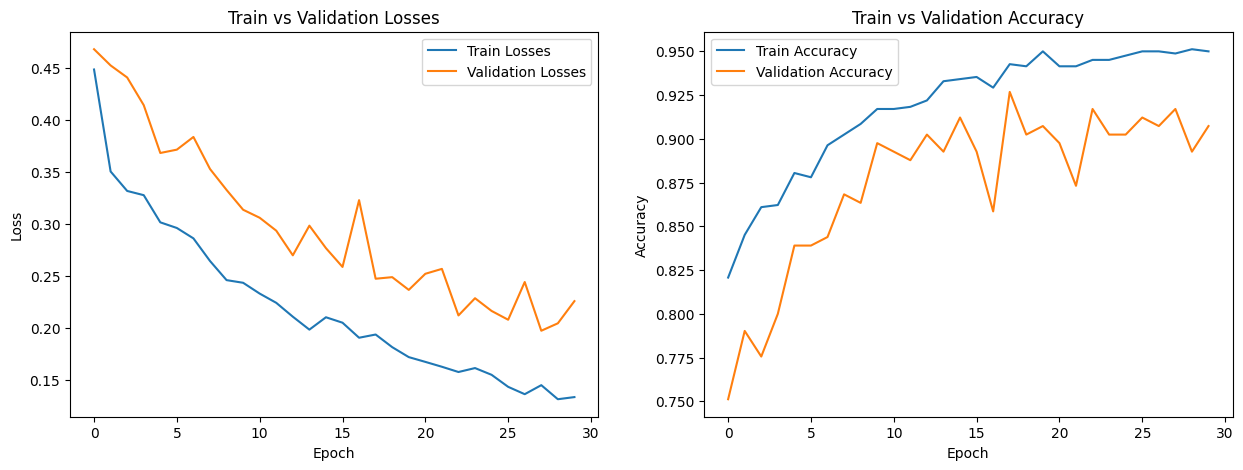

In [ ]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_test_t  = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.long)

size_of_batch = 16
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=size_of_batch,
                          shuffle=True)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=size_of_batch,
                         shuffle=False)

# 1
class FeedforwardNeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeedforwardNeuralNetwork, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)

        return out

input_dim = X_train.shape[1]
hidden_dim = 16
output_dim = 2
model = FeedforwardNeuralNetwork(input_dim, hidden_dim, output_dim)

# 2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3 + 4
epochs = 30
train_losses, test_losses = [], []
train_acc, test_acc = [], []

for epoch in range(epochs):

    model.train()
    total_loss, correct, total = 0, 0, 0

    for i, (features, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(total_loss / len(train_loader))
    train_acc.append(correct / total)

    model.eval()
    total_loss, correct, total = 0, 0, 0

    for features, labels in test_loader:
        outputs = model(features)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    test_losses.append(total_loss / len(test_loader))
    test_acc.append(correct / total)

    print(f'[Epoch: {epoch+1}/{epochs} '
          f'| Train Loss: {train_losses[-1]:.4f} '
          f'| Test Loss: {test_losses[-1]:.4f} '
          f'| Train Acc: {train_acc[-1]*100:.2f}% '
          f'| Test Acc: {test_acc[-1]*100:.2f}% ]')

# 5
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Losses')
plt.plot(test_losses, label='Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Validation Losses')

plt.subplot(1,2,2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')

plt.show()


# Materiały z których kozystałem dla wykonania zadania
# https://www.deeplearningwizard.com/deep_learning/practical_pytorch/pytorch_feedforward_neuralnetwork/#steps_2
# https://www.geeksforgeeks.org/deep-learning/activation-function-in-tensorflow/
# https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

## 3. Interpretacja wyników

1. Sprawdź, w której epoce model osiągnął najlepszą dokładność na zbiorze walidacyjnym.
2. Zinterpretuj wykresy strat i dokładności – czy model się przeucza (overfitting)?
3. Zapisz wnioski w 2-3 zdaniach.

In [ ]:
best_epoch = test_acc.index(max(test_acc)) +1
best_accuracy = max(test_acc)*100

print(f'Najlepsza dokładność osiągnięto w epoce {best_epoch} [na zbiorze walidacyjnym]'
      f' z wartością {best_accuracy:.2f}%')

Najlepsza dokładność osiągnięto w epoce 30 [na zbiorze walidacyjnym] z wartością 94.63%


# Interprytcaja wykresów
1. Strata treningowa maleje prawie w każdej epoce
2. Strata walidacyjna również systematycznie się zmniejsza
3. Poziom dokładności zarówno na zbiorze treningowym, jak i testowym jest dość wysoki
Na podstawie tych obserwacji można stwierdzić, że model nie wykazuje oznak overfittingu

# Wnioski
1. Zauważyłem, że przy mniejszych rozmiarach batcha model osiągał wyższą dokładność w najlepszej epoce (ale na zbyt małych batchach jest gorzej).
2. Czytając informacje o funkcji nieliniowej w modelu na stronie https://www.deeplearningwizard.com/deep_learning/practical_pytorch/pytorch_feedforward_neuralnetwork/#introducing-a-non-linear-function doszedłem do wniosku, że Relu jest jednym z najlepszych wyborów do pracy ze względu na swoją szybkość w porównaniu z funkcją Sigmoid i Tanh, a dzięki niej można szybko sprawdzić, czy nasz zbiór danych nadaje się do uczenia.
3. Większa liczba epok zazwyczaj poprawia dokładność modelu na danych treningowych, jednak może prowadzić do overfittingu, jeśli model trenuje zbyt długo na tych samych danych.
